<a href="https://colab.research.google.com/github/Sarah4045/Time-Series/blob/main/Another_copy_of_Data_analysis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1-Leen Hussain- 44510029

2-Ajwan Turki - 44510931

3-Nuha Mansur - 44410935

4-Shroog AL-harbi - 445000148

Section(1)

Importing libraries and reading the file

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import PolynomialFeatures

df = pd.read_csv("Student Depression Dataset.csv")

LAB 1



1.Cleaning The Dataset

In [ ]:
#printing dataset before
print("Missing values before:")
print(df)

Missing values before:
           id  Gender   Age           City Profession  Academic Pressure  \
0           2    Male  33.0  Visakhapatnam    Student                5.0   
1           8  Female  24.0      Bangalore    Student                2.0   
2          26    Male  31.0       Srinagar    Student                3.0   
3          30  Female  28.0       Varanasi    Student                3.0   
4          32  Female  25.0         Jaipur    Student                4.0   
...       ...     ...   ...            ...        ...                ...   
27896  140685  Female  27.0          Surat    Student                5.0   
27897  140686    Male  27.0       Ludhiana    Student                2.0   
27898  140689    Male  31.0      Faridabad    Student                3.0   
27899  140690  Female  18.0       Ludhiana    Student                5.0   
27900  140699    Male  27.0          Patna    Student                4.0   

       Work Pressure  CGPA  Study Satisfaction  Job Satisfaction

In [ ]:
#Deleting missing values
df = df.dropna()

In [ ]:
#printing dataset after, the row are now 27898 instead of 27901 which mean that there was missing values
print("Missing values after:")
print(df)

Missing values after:
           id  Gender   Age           City Profession  Academic Pressure  \
0           2    Male  33.0  Visakhapatnam    Student                5.0   
1           8  Female  24.0      Bangalore    Student                2.0   
2          26    Male  31.0       Srinagar    Student                3.0   
3          30  Female  28.0       Varanasi    Student                3.0   
4          32  Female  25.0         Jaipur    Student                4.0   
...       ...     ...   ...            ...        ...                ...   
27896  140685  Female  27.0          Surat    Student                5.0   
27897  140686    Male  27.0       Ludhiana    Student                2.0   
27898  140689    Male  31.0      Faridabad    Student                3.0   
27899  140690  Female  18.0       Ludhiana    Student                5.0   
27900  140699    Male  27.0          Patna    Student                4.0   

       Work Pressure  CGPA  Study Satisfaction  Job Satisfaction 

In [ ]:
#printing duplicated values before
print("Duplicated values before:")
print(df)

Duplicated values before:
           id  Gender   Age           City Profession  Academic Pressure  \
0           2    Male  33.0  Visakhapatnam    Student                5.0   
1           8  Female  24.0      Bangalore    Student                2.0   
2          26    Male  31.0       Srinagar    Student                3.0   
3          30  Female  28.0       Varanasi    Student                3.0   
4          32  Female  25.0         Jaipur    Student                4.0   
...       ...     ...   ...            ...        ...                ...   
27896  140685  Female  27.0          Surat    Student                5.0   
27897  140686    Male  27.0       Ludhiana    Student                2.0   
27898  140689    Male  31.0      Faridabad    Student                3.0   
27899  140690  Female  18.0       Ludhiana    Student                5.0   
27900  140699    Male  27.0          Patna    Student                4.0   

       Work Pressure  CGPA  Study Satisfaction  Job Satisfact

In [ ]:
#Deleting duplicated values
df = df.drop_duplicates()

In [ ]:
#printing duplicated values after, there weren't any duplicated values since the number of rows hasn't changed
print("Duplicated values after:")
print(df)

Duplicated values after:
           id  Gender   Age           City Profession  Academic Pressure  \
0           2    Male  33.0  Visakhapatnam    Student                5.0   
1           8  Female  24.0      Bangalore    Student                2.0   
2          26    Male  31.0       Srinagar    Student                3.0   
3          30  Female  28.0       Varanasi    Student                3.0   
4          32  Female  25.0         Jaipur    Student                4.0   
...       ...     ...   ...            ...        ...                ...   
27896  140685  Female  27.0          Surat    Student                5.0   
27897  140686    Male  27.0       Ludhiana    Student                2.0   
27898  140689    Male  31.0      Faridabad    Student                3.0   
27899  140690  Female  18.0       Ludhiana    Student                5.0   
27900  140699    Male  27.0          Patna    Student                4.0   

       Work Pressure  CGPA  Study Satisfaction  Job Satisfacti

2.Normalization of values

In [ ]:
#Normalize numeric values ​​only
print("Data before selecting numeric columns:")
print(df.head())  # طباعة أول 5 صفوف من البيانات

numeric_columns = df.select_dtypes(include=['number']).columns

scaler = MinMaxScaler()
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])
print("Data after selecting numeric columns:")
print(df[numeric_columns].head())

Data before selecting numeric columns:
   id  Gender   Age           City Profession  Academic Pressure  \
0   2    Male  33.0  Visakhapatnam    Student                5.0   
1   8  Female  24.0      Bangalore    Student                2.0   
2  26    Male  31.0       Srinagar    Student                3.0   
3  30  Female  28.0       Varanasi    Student                3.0   
4  32  Female  25.0         Jaipur    Student                4.0   

   Work Pressure  CGPA  Study Satisfaction  Job Satisfaction  \
0            0.0  8.97                 2.0               0.0   
1            0.0  5.90                 5.0               0.0   
2            0.0  7.03                 5.0               0.0   
3            0.0  5.59                 2.0               0.0   
4            0.0  8.13                 3.0               0.0   

      Sleep Duration Dietary Habits   Degree  \
0          5-6 hours        Healthy  B.Pharm   
1          5-6 hours       Moderate      BSc   
2  Less than 5 hours   

3.Addressing outliers

In [ ]:
#addressing outliers معالجة القيم المتطرفة
print("the data set befor addressing outliers")#طباعة للداتاسيت قبل المعالجة
print(df.head())

the data set befor addressing outliers
         id  Gender       Age           City Profession  Academic Pressure  \
0  0.000000    Male  0.365854  Visakhapatnam    Student                1.0   
1  0.000043  Female  0.146341      Bangalore    Student                0.4   
2  0.000171    Male  0.317073       Srinagar    Student                0.6   
3  0.000199  Female  0.243902       Varanasi    Student                0.6   
4  0.000213  Female  0.170732         Jaipur    Student                0.8   

   Work Pressure   CGPA  Study Satisfaction  Job Satisfaction  \
0            0.0  0.897                 0.4               0.0   
1            0.0  0.590                 1.0               0.0   
2            0.0  0.703                 1.0               0.0   
3            0.0  0.559                 0.4               0.0   
4            0.0  0.813                 0.6               0.0   

      Sleep Duration Dietary Habits   Degree  \
0          5-6 hours        Healthy  B.Pharm   
1    

In [ ]:
numerical_columns = ["Age", "Academic Pressure", "Work Pressure", "CGPA",
                     "Study Satisfaction", "Job Satisfaction", "Work/Study Hours",
                     "Financial Stress", "Depression"]


def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

outlier_counts = {}
for col in numerical_columns:
    outliers = detect_outliers_iqr(df, col)
    outlier_counts[col] = len(outliers)
    print("number of outlirs'{col}': {len(outliers)}")

    if not outliers.empty:
        print(outliers[[col]].head())

print("\n**summarry outlirs**")
for col, count in outlier_counts.items():
    print(f"{col}: {count}  outrlirs")

number of outlirs'{col}': {len(outliers)}
           Age
2909  0.975610
3436  0.756098
4386  0.804878
5537  0.634146
9006  0.682927
number of outlirs'{col}': {len(outliers)}
number of outlirs'{col}': {len(outliers)}
       Work Pressure
4365             1.0
14855            0.4
25746            1.0
number of outlirs'{col}': {len(outliers)}
       CGPA
4365    0.0
10407   0.0
11489   0.0
13909   0.0
14855   0.0
number of outlirs'{col}': {len(outliers)}
number of outlirs'{col}': {len(outliers)}
       Job Satisfaction
292                0.75
4365               1.00
13909              0.50
14855              0.25
20913              0.25
number of outlirs'{col}': {len(outliers)}
number of outlirs'{col}': {len(outliers)}
number of outlirs'{col}': {len(outliers)}

**summarry outlirs**
Age: 12  outrlirs
Academic Pressure: 0  outrlirs
Work Pressure: 3  outrlirs
CGPA: 9  outrlirs
Study Satisfaction: 0  outrlirs
Job Satisfaction: 8  outrlirs
Work/Study Hours: 0  outrlirs
Financial Stress: 0  out

In [ ]:
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # إزالة الصفوف التي تحتوي على قيم متطرفة
    cleaned_data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return cleaned_data
    #عدد الصفوف قبل  الحذف
print(f" number of row befor remove outlirs: {df.shape[0]}")

# حذف القيم المتطرفة
for col in numerical_columns:
    df = remove_outliers_iqr(df, col)

# عدد الصفوف بعد  الحذف
print(f" number of row after remov outlirs {df.shape[0]}")

 number of row befor remove outlirs: 27898
 number of row after remov outlirs 27875


In [ ]:
#طباعة الداتا بعد معالجة القيم المتطرفة وحذفها
print(" dataset aftar addressing outliers:")
print(df.head())

 dataset aftar addressing outliers:
         id  Gender       Age           City Profession  Academic Pressure  \
0  0.000000    Male  0.365854  Visakhapatnam    Student                1.0   
1  0.000043  Female  0.146341      Bangalore    Student                0.4   
2  0.000171    Male  0.317073       Srinagar    Student                0.6   
3  0.000199  Female  0.243902       Varanasi    Student                0.6   
4  0.000213  Female  0.170732         Jaipur    Student                0.8   

   Work Pressure   CGPA  Study Satisfaction  Job Satisfaction  \
0            0.0  0.897                 0.4               0.0   
1            0.0  0.590                 1.0               0.0   
2            0.0  0.703                 1.0               0.0   
3            0.0  0.559                 0.4               0.0   
4            0.0  0.813                 0.6               0.0   

      Sleep Duration Dietary Habits   Degree  \
0          5-6 hours        Healthy  B.Pharm   
1       

In [ ]:
# تغيير نوع data type
df["Depression"] = df["Depression"].astype(int)
df["Age"] = df["Age"].astype(int)
print(df)

             id  Gender  Age           City Profession  Academic Pressure  \
0      0.000000    Male    0  Visakhapatnam    Student                1.0   
1      0.000043  Female    0      Bangalore    Student                0.4   
2      0.000171    Male    0       Srinagar    Student                0.6   
3      0.000199  Female    0       Varanasi    Student                0.6   
4      0.000213  Female    0         Jaipur    Student                0.8   
...         ...     ...  ...            ...        ...                ...   
27896  0.999900  Female    0          Surat    Student                1.0   
27897  0.999908    Male    0       Ludhiana    Student                0.4   
27898  0.999929    Male    0      Faridabad    Student                0.6   
27899  0.999936  Female    0       Ludhiana    Student                1.0   
27900  1.000000    Male    0          Patna    Student                0.8   

       Work Pressure   CGPA  Study Satisfaction  Job Satisfaction  \
0     

In [ ]:
# لتخلص من القيم null يتم حط مكانها المتوسط
df["Financial Stress"] = df["Financial Stress"].fillna(df["Financial Stress"].median())
print(df)

             id  Gender  Age           City Profession  Academic Pressure  \
0      0.000000    Male    0  Visakhapatnam    Student                1.0   
1      0.000043  Female    0      Bangalore    Student                0.4   
2      0.000171    Male    0       Srinagar    Student                0.6   
3      0.000199  Female    0       Varanasi    Student                0.6   
4      0.000213  Female    0         Jaipur    Student                0.8   
...         ...     ...  ...            ...        ...                ...   
27896  0.999900  Female    0          Surat    Student                1.0   
27897  0.999908    Male    0       Ludhiana    Student                0.4   
27898  0.999929    Male    0      Faridabad    Student                0.6   
27899  0.999936  Female    0       Ludhiana    Student                1.0   
27900  1.000000    Male    0          Patna    Student                0.8   

       Work Pressure   CGPA  Study Satisfaction  Job Satisfaction  \
0     

In [ ]:
#  معرفة الداتا وعدد الاعمد والصفوف و data type لكل عمود
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27875 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27875 non-null  float64
 1   Gender                                 27875 non-null  object 
 2   Age                                    27875 non-null  int64  
 3   City                                   27875 non-null  object 
 4   Profession                             27875 non-null  object 
 5   Academic Pressure                      27875 non-null  float64
 6   Work Pressure                          27875 non-null  float64
 7   CGPA                                   27875 non-null  float64
 8   Study Satisfaction                     27875 non-null  float64
 9   Job Satisfaction                       27875 non-null  float64
 10  Sleep Duration                         27875 non-null  object 
 11  Dietary

In [ ]:
# التأكد من عدم وجود قيم المفقودة
df.isnull().sum()

,0
id,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0


Part 2: Linear and Nonlinear Regression

In [ ]:
#Sample linear regression
X = df[['CGPA']]
y = df['Work/Study Hours']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

model = LinearRegression()
model.fit(X_poly_train, y_train)

y_pred = model.predict(X_poly_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))

print("Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"Adjusted R² Score: {adjusted_r2:.2f}")

Model Evaluation:
Mean Squared Error (MSE): 0.09
Root Mean Squared Error (RMSE): 0.31
R² Score: 0.00
Adjusted R² Score: 0.00


In [ ]:
#Multi Linear regression

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[['CGPA', 'Work/Study Hours']]
y = df['Work/Study Hours']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

model = LinearRegression()
model.fit(X_poly_train, y_train)

y_pred = model.predict(X_poly_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))

print("Model Evaluation:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")
print(f"Adjusted R² Score: {adjusted_r2:.2f}")

Model Evaluation:
Mean Squared Error (MSE): 0.00
Root Mean Squared Error (RMSE): 0.00
R² Score: 1.00
Adjusted R² Score: 1.00


In [ ]:
#Key-fold cross map

features = ['CGPA']
X = df[features]
y = df['Work/Study Hours']

model = LinearRegression()

kf = KFold(n_splits=5, random_state=42, shuffle=True)

cv_results_mse = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
cv_mse = -cv_results_mse
cv_rmse = np.sqrt(cv_mse)

mean_mse = cv_mse.mean()
mean_rmse = cv_rmse.mean()

cv_results_r2 = cross_val_score(model, X, y, cv=kf, scoring='r2')
mean_r2 = cv_results_r2.mean()

n = X.shape[0]
p = X.shape[1]
adjusted_r2 = 1 - (1 - mean_r2) * ((n - 1) / (n - p - 1))

print("K-Fold Cross Validation (5 splits):")
print(f"MSE (each fold): {cv_mse}")
print(f"Mean MSE across all folds: {mean_mse:.2f}")
print(f"RMSE (each fold): {cv_rmse}")
print(f"Mean RMSE across all folds: {mean_rmse:.2f}")
print(f"Mean R² across all folds: {mean_r2:.2f}")
print(f"Adjusted R²: {adjusted_r2:.2f}")

K-Fold Cross Validation (5 splits):
MSE (each fold): [0.09459462 0.09479437 0.09571644 0.09550771 0.09663872]
Mean MSE across all folds: 0.10
RMSE (each fold): [0.30756238 0.30788694 0.30938073 0.30904322 0.31086769]
Mean RMSE across all folds: 0.31
Mean R² across all folds: -0.00
Adjusted R²: -0.00


Visualization

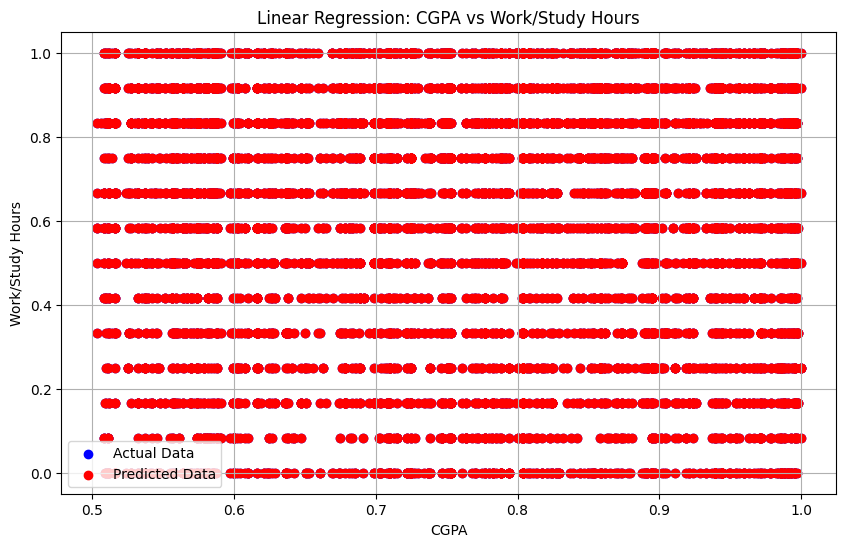

In [ ]:
import matplotlib.pyplot as plt

# رسم المخطط البياني ثنائي الأبعاد
plt.figure(figsize=(10, 6))

# نقاط البيانات الفعلية
plt.scatter(X_test['CGPA'], y_test, color='blue', label='Actual Data')

# التنبؤ باستخدام النموذج
plt.scatter(X_test['CGPA'], y_pred, color='red', label='Predicted Data')

plt.xlabel('CGPA')
plt.ylabel('Work/Study Hours')
plt.title('Linear Regression: CGPA vs Work/Study Hours')
plt.legend()
plt.grid(True)
plt.show()

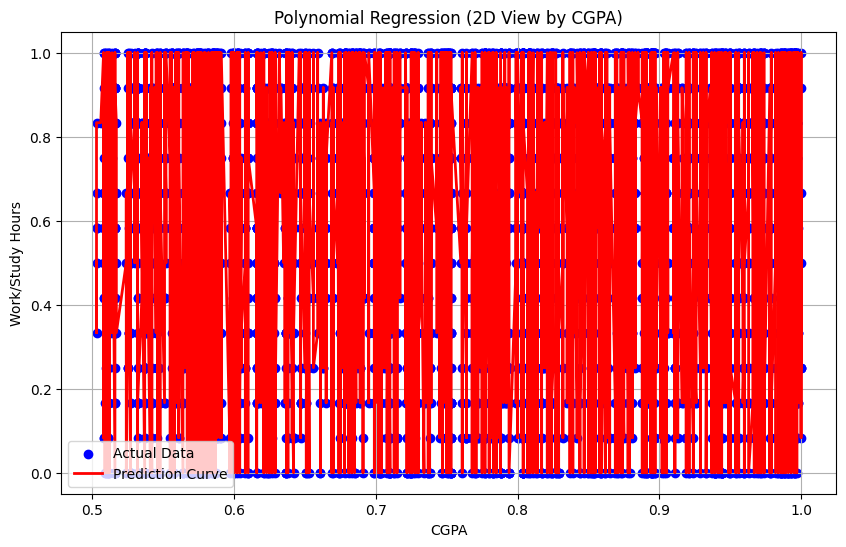

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# اختيار feature واحد فقط لعرضه على المحور X (مثلاً CGPA)
x = X_test['CGPA']
y_actual = y_test
y_predicted = y_pred

# ترتيب القيم لرسم خط ناعم
sorted_indices = x.argsort()
x_sorted = x.iloc[sorted_indices]
y_pred_sorted = y_predicted[sorted_indices]

# الرسم
plt.figure(figsize=(10, 6))
plt.scatter(x, y_actual, color='blue', label='Actual Data')
plt.plot(x_sorted, y_pred_sorted, color='red', linewidth=2, label='Prediction Curve')

plt.xlabel('CGPA')
plt.ylabel('Work/Study Hours')
plt.title('Polynomial Regression (2D View by CGPA)')
plt.legend()
plt.grid(True)
plt.show()

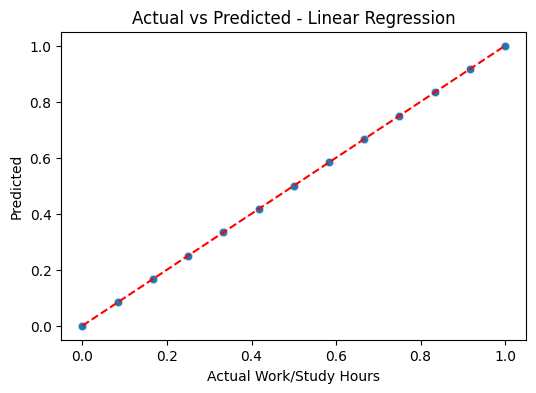

In [ ]:
import seaborn as sns # Import the seaborn library and alias it as 'sns'
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Actual Work/Study Hours")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted - Linear Regression")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # خط المثالية
plt.show()

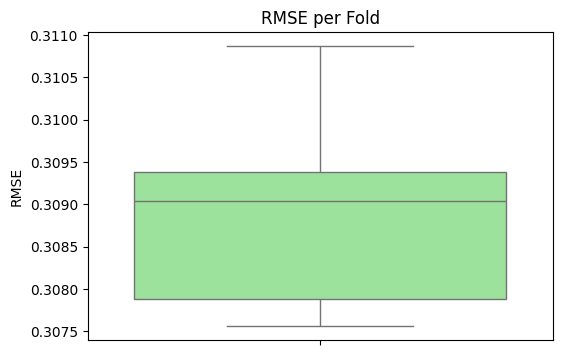

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=cv_rmse, color='lightgreen')
plt.title("RMSE per Fold")
plt.ylabel("RMSE")
plt.show()

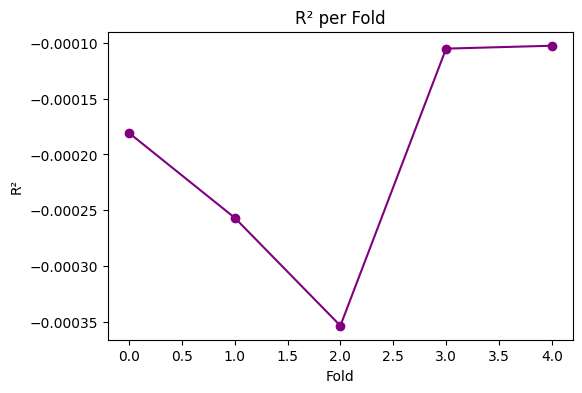

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(cv_results_r2, marker='o', color='purple')
plt.title("R² per Fold")
plt.xlabel("Fold")
plt.ylabel("R²")
plt.show()